## Notebook 2 - VDOS of crystal and irradiated graphite

To make progress on the understanding of diffusivity and VDOS in irradiated graphite, we will compare VDOS of irradiated graphite with VDOS of crystal graphite to ensure comparison is made on equal footing.

In this notebook we will:

- calculate VDOS and average group velocity of crystal graphite as a function of frequency
- plot VDOS of crystal and irradiated graphite on the same plot
- finally, analyze differences between VDOS in the two systems

In [1]:
# load the libraries and the reference code
import sys

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ase.io import read

from tqdm import tqdm

from smooth_disorder.structural import obtain_density, THzToCm, THz, Angstrom
from smooth_disorder.vis.interactive import *

from smooth_disorder.disorder_linewidth import lorentzian_numpy, flatten_arrays
from smooth_disorder.disorder_linewidth import calculate_vdos_and_average_speed_with_frequency
from smooth_disorder.disorder_linewidth import save_vdos_speed_data_to_files

In [2]:
# POSCAR, define output folders
CRYSTAL_POSCAR   = "./1_graphite/POSCAR"
DISORDERED_POSCAR      = "./2_irg_t2/irg_t2_14009.vasp"

WORK_DIR = "./dl_tutorial"

MESH_SAVE        = f"{WORK_DIR}/mesh_data"
CRYSTAL_VEL_SAVE      = f"{WORK_DIR}/crystal_vdos_group_vel"
DISORDERED_VDOS_SAVE  = f"{WORK_DIR}/disordered_vdos"

# Lorentzian half-width η for VDOS broadening [cm⁻¹].
# Controls spectral resolution — typical value for graphite: 0.6 cm⁻¹.
GAMMA_BROADENING = 0.6

In [3]:
# 1. load the quantities from the previous notebook
# 2. flatten them to enable quick calculation of the VDOS
# 3. Calculate VDOS and average speed as a function of frequency

with h5py.File(f"{MESH_SAVE}.hdf5", "r") as f:
    frequencies_cm      = np.asarray(f["frequencies_cm"])       # (N_qpts, N_bands) [cm⁻¹]
    weights             = np.asarray(f["weights"])              # (N_qpts,)
    qpoints             = np.asarray(f["qpoints"])              # (N_qpts, 3) fractional
    group_velocities_ms = np.asarray(f["group_velocities_ms"])  # (N_qpts, N_bands, 3) [m/s]


frequencies_flat, weights_flat, speed_flat, weights_sum = flatten_arrays(
    frequencies_cm,
    weights,
    group_velocities_ms)

vdos_crystal, speed_crystal, freq_crystal = calculate_vdos_and_average_speed_with_frequency(
    frequencies_flat,
    weights_flat,
    speed_flat,
    GAMMA_BROADENING,
    CRYSTAL_POSCAR,
    weights_sum
)

VDOS & v(w): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13396/13396 [01:23<00:00, 161.03it/s]


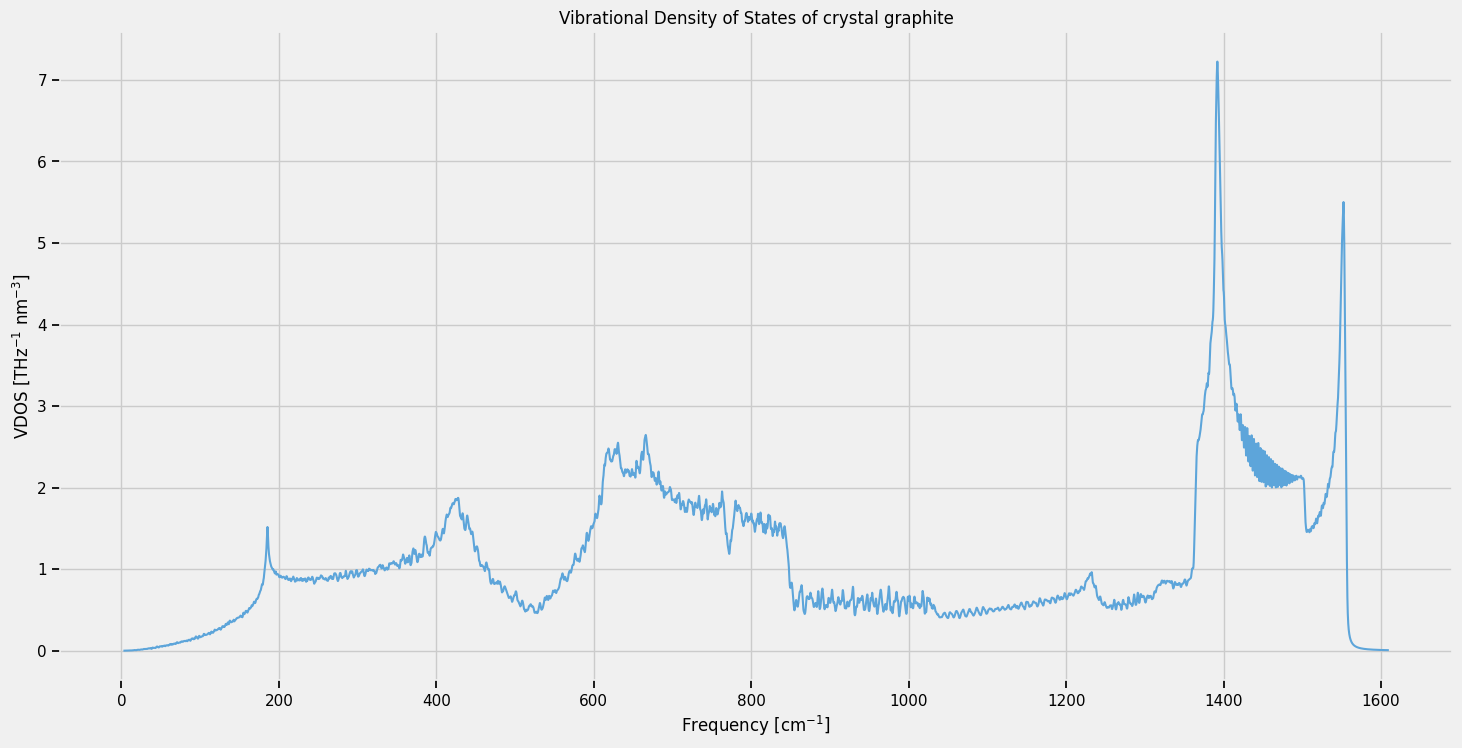

In [4]:
# plot the results

plt.figure(figsize=(16, 8))

plt.plot(freq_crystal, vdos_crystal, color=Colors[3])

plt.xlabel(r"Frequency [cm$^{-1}$]")
plt.ylabel(r"VDOS [THz$^{-1}$ nm$^{-3}$]")

plt.title("Vibrational Density of States of crystal graphite")

plt.show()


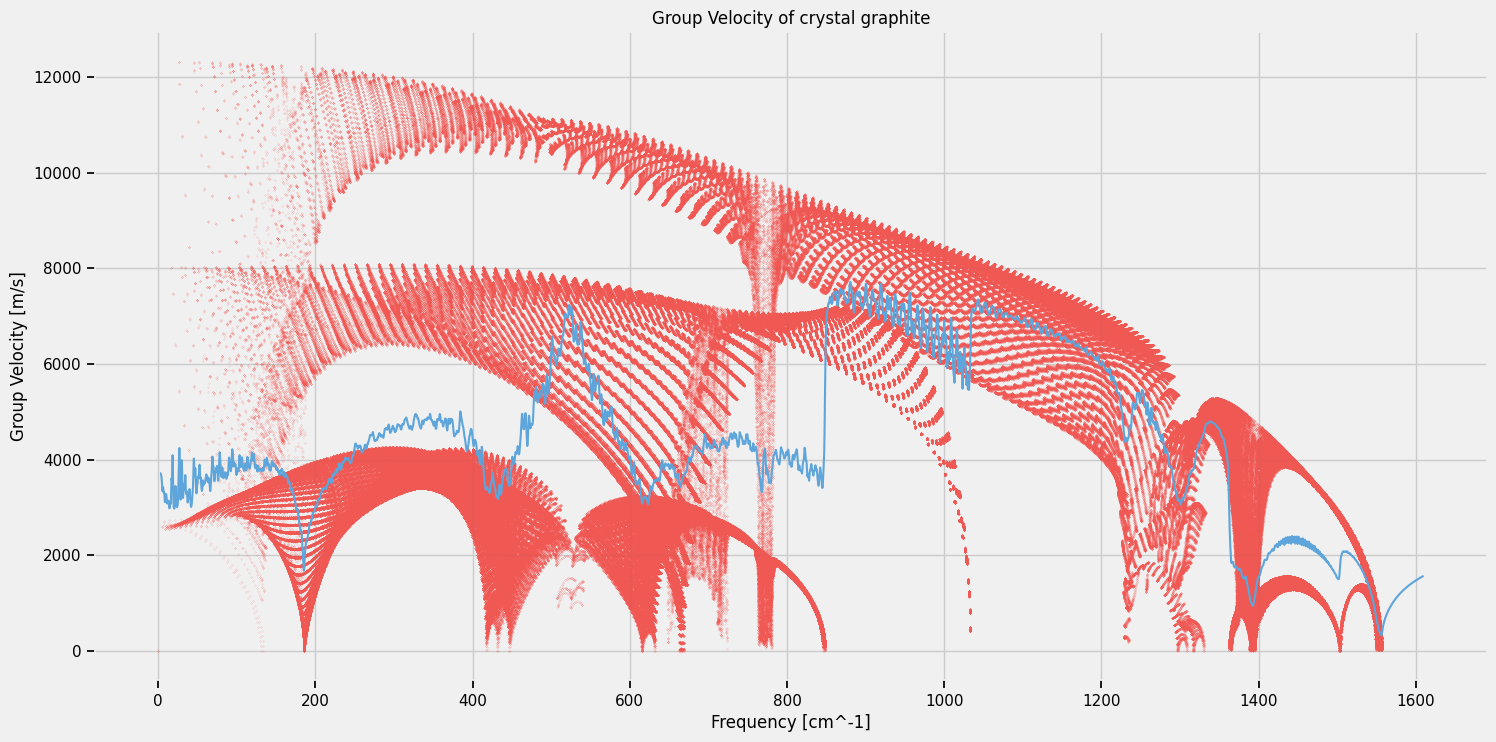

In [5]:
plt.figure(figsize=(16, 8))

speed_2d = np.sqrt(
    np.square(group_velocities_ms).sum(axis=2) / 3
)

plt.scatter(frequencies_cm, speed_2d, color=Colors[0], s=0.01)

# the average of the group velocities at a given frequency
plt.plot(freq_crystal, speed_crystal, color=Colors[3])

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Group Velocity [m/s]")

plt.title("Group Velocity of crystal graphite")

plt.show()

We see that the average speed is averaged with the help of the VDOS. In areas where there is high density of modes with low group velocity (e.g., 100-400 cm$^{-1}$), the average speed is about 4000 m/s, when we average in parts without those modes, it increases to 7000 m/s (900-1100 cm$^{-1}$ range)

In [6]:
save_vdos_speed_data_to_files(CRYSTAL_VEL_SAVE, freq_crystal, vdos_crystal, speed_crystal)

### Read in VDOS of irradiated graphite, and compare with crystal graphite VDOS

In [7]:
with h5py.File(f"{DISORDERED_VDOS_SAVE}.hdf5", "r") as f:
    freq_disordered = np.asarray(f["frequencies_bin"])   # [cm⁻¹]
    vdos_disordered = np.asarray(f["vdos_return"])       # [THz⁻¹ nm⁻³]

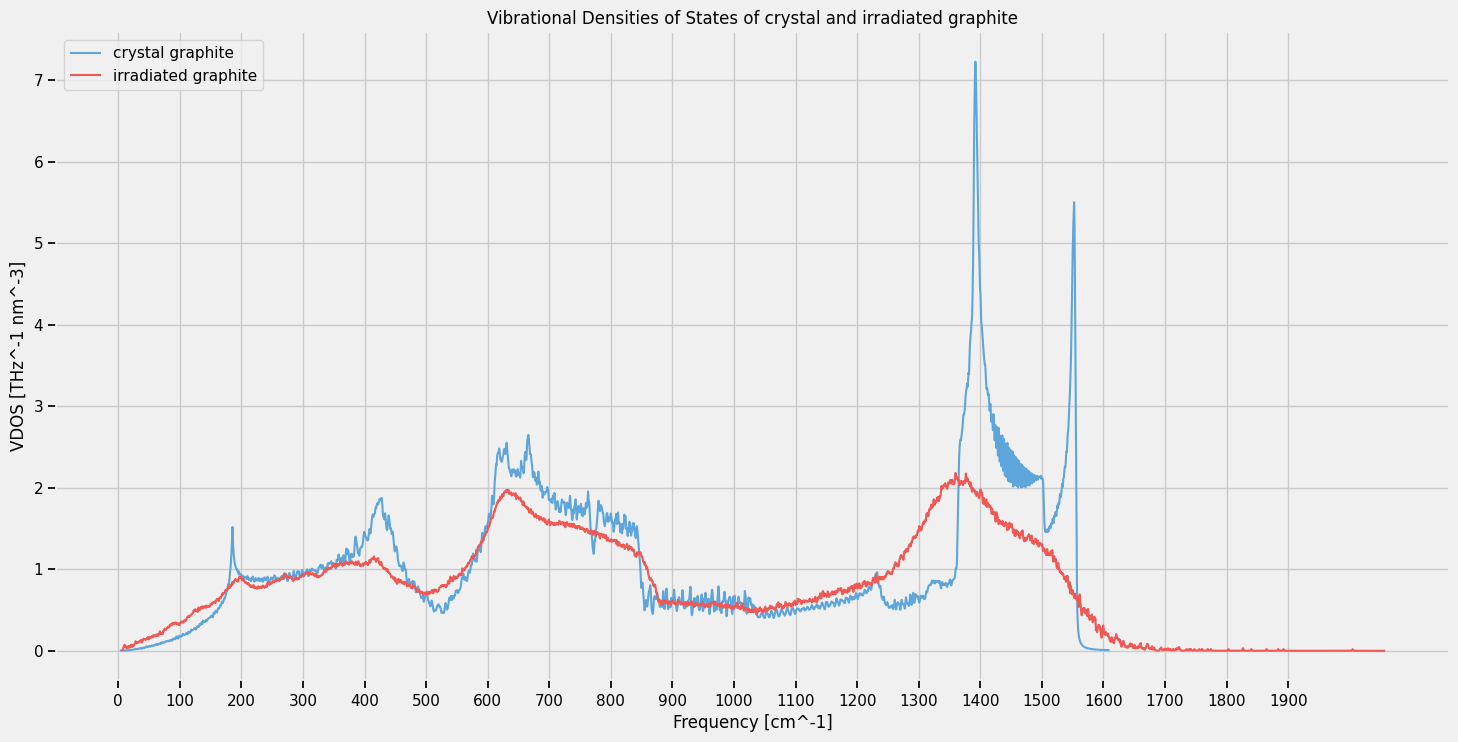

In [8]:
plt.figure(figsize=(16, 8))

plt.plot(freq_crystal, vdos_crystal, color=Colors[3], label="crystal graphite")
plt.plot(freq_disordered, vdos_disordered, color=Colors[0], label='irradiated graphite')

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("VDOS [THz^-1 nm^-3]")

plt.title("Vibrational Densities of States of crystal and irradiated graphite")

plt.xticks(np.arange(0, 2000, 100))

plt.legend(loc='upper left')

plt.show()

We find there are three main effects of disorder on the VDOS in irradiated graphite: 
- (1) VDOS of the disordered system is smoother compared with the crystalline reference
- (2) Density of the irradiated graphite is lower than that of the crystal graphite, this causes shift of the peaks to lower frequencies (see third notebook for exploration of this phenomenon) and
- (3) lower normalization of the VDOS due to the VDOS definition that includes unit cell volume:

In [9]:
# magnitude changes
(vdos_crystal * (freq_crystal[1] - freq_crystal[0])).sum()

np.float64(1771.1361453350669)

In [10]:
(vdos_disordered * (freq_disordered[1] - freq_disordered[0])).sum()

np.float64(1587.278672661441)